In [1]:
import pandas as	pd
import numpy as np
import	matplotlib.pyplot as plt
import	seaborn as sns

**Load cleaned_data.csv from Part 1. Define:**

In [2]:
df=pd.read_csv("cleaned_housing_data.csv")

In [3]:
df.shape

(250000, 20)

Feature matrix X: all columns except the target.
Regression label y_reg: one continuous numeric column (e.g., price, income).

In [4]:
X=df.drop(columns=['Price_in_Lakhs'])
y_reg=df['Price_in_Lakhs']


In [5]:
X.shape

(250000, 19)

In [6]:
y_clf = (y_reg > y_reg.median()).astype(int)

In [7]:
X.head(2)

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,Maharashtra,Pune,Locality_490,Independent House,3,2364,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction


1.State
city
locality
property_type
furnished
Amenities
Facing	
Public_Transport_Accessibility,,Owner_Parking_SpaceType,Availability_Status, orinal encoding 

Classification label y_clf: a binary column derived by binarizing y_reg at its median (y_clf = (y_reg > y_reg.median()).astype(int)) or another natural binary column in the dataset. State both label definitions clearly in the README.

**Encode categorical columns: For each categorical column in X:**

**Ordinal encoding**

In [8]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [9]:
Lab=LabelEncoder()

In [10]:
X["Public_Transport_Accessibility"]=Lab.fit_transform(X["Public_Transport_Accessibility"])
X["Parking_Space"]=Lab.fit_transform(X["Parking_Space"])
X["Security"]=Lab.fit_transform(X["Security"])

**ONEhot encoding**

In [11]:
X_encoded = pd.get_dummies(
    X[['State','City','Locality','Property_Type',"Furnished_Status","Facing","Amenities","Owner_Type","Availability_Status"]],
        dtype='int',sparse=True,
    drop_first=True
)

In [12]:
X_final=pd.DataFrame(X_encoded)


In [13]:
X.drop(columns=['State','City','Locality','Property_Type',"Furnished_Status","Facing","Amenities","Owner_Type","Availability_Status"], inplace=True)

In [14]:
X.columns

Index(['BHK', 'Size_in_SqFt', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security'],
      dtype='object')

In [15]:
X.head(2)

,BHK,Size_in_SqFt,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security
0,1,4740,22,1,35,10,3,0,0,0
1,3,2364,21,20,17,8,1,1,0,1


In [16]:
X_final=pd.concat([X.reset_index(drop=True), X_final.reset_index(drop=True)], axis=1)

In [17]:
X_final.head(2)

,BHK,Size_in_SqFt,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,...,"Amenities_Pool, Playground, Garden, Gym","Amenities_Pool, Playground, Garden, Gym, Clubhouse","Amenities_Pool, Playground, Gym","Amenities_Pool, Playground, Gym, Clubhouse","Amenities_Pool, Playground, Gym, Clubhouse, Garden","Amenities_Pool, Playground, Gym, Garden","Amenities_Pool, Playground, Gym, Garden, Clubhouse",Owner_Type_Builder,Owner_Type_Owner,Availability_Status_Under_Construction
0,1,4740,22,1,35,10,3,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,3,2364,21,20,17,8,1,1,0,1,...,0,0,0,0,0,0,0,1,0,1


In [18]:
X_final=X_final.iloc[:100000]
y_reg=df['Price_in_Lakhs'].iloc[:100000]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_reg, test_size=0.2, random_state=42)


In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80000, 903), (20000, 903), (80000,), (20000,))

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [22]:
scaler.fit(X_train)

c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,copy,True
,with_mean,True
,with_std,True


In [23]:
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


**Regression model — Linear Regression:**

Train a LinearRegression model from sklearn.linear_model on the scaled training features and y_reg_train.
Predict on X_test_scaled to get y_pred_reg.
Compute and report: MSE using mean_squared_error(y_reg_test, y_pred_reg) and R² using r2_score(y_reg_test, y_pred_reg).
Print the model's coefficients alongside the corresponding feature names. Identify the three features with the largest absolute coefficient values. In the README, interpret what a large positive coefficient means (as one unit increase in the scaled feature is associated with how many units increase in the predicted value) and what a large negative coefficient means.
Apply Ridge Regression (Ridge(alpha=1.0)) using the same split and scaling. Compare its MSE and R² against plain Linear Regression in a two-row comparison table in the README. Explain in one paragraph why Ridge might produce a different coefficient profile than OLS Linear Regression and what the alpha parameter controls.

In [24]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [25]:
LR.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = LR.predict(X_test_scaled)

In [27]:
from sklearn.metrics import mean_squared_error, r2_score


print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 20042.830056558854
R^2 Score: -0.008688873894596272


In [28]:
# Build DataFrame of coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": LR.coef_
})

# Add absolute values for comparison
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

# Sort by absolute value
coef_df_sorted = coef_df.sort_values(by="AbsCoefficient", ascending=False)

# Largest absolute coefficient
largest_abs = coef_df_sorted.iloc[0]
print("Largest absolute coefficient:")
print(largest_abs)

# Largest negative coefficient (most negative raw value)
largest_neg = coef_df.loc[coef_df["Coefficient"].idxmin()]
print("\nLargest negative coefficient:")
print(largest_neg)

Largest absolute coefficient:
Feature           Amenities_Playground, Pool, Garden
Coefficient                                 1.694765
AbsCoefficient                              1.694765
Name: 825, dtype: object

Largest negative coefficient:
Feature           Locality_Locality_251
Coefficient                   -1.294415
AbsCoefficient                 1.294415
Name: 238, dtype: object


In [29]:
importance=pd.DataFrame({
				"Feature": X_train.columns,		
     "coefficient": LR.coef_})
importance.sort_values(by="coefficient", ascending=False,key=abs)

,Feature,coefficient
825,"Amenities_Playground, Pool, Garden",1.694765
216,Locality_Locality_231,1.570403
397,Locality_Locality_395,1.549516
568,Locality_Locality_99,1.427272
126,Locality_Locality_150,1.393185
...,...,...
145,Locality_Locality_168,-0.005672
74,Locality_Locality_103,-0.005601
419,Locality_Locality_414,0.002448
637,"Amenities_Clubhouse, Pool, Playground, Garden,...",-0.002057


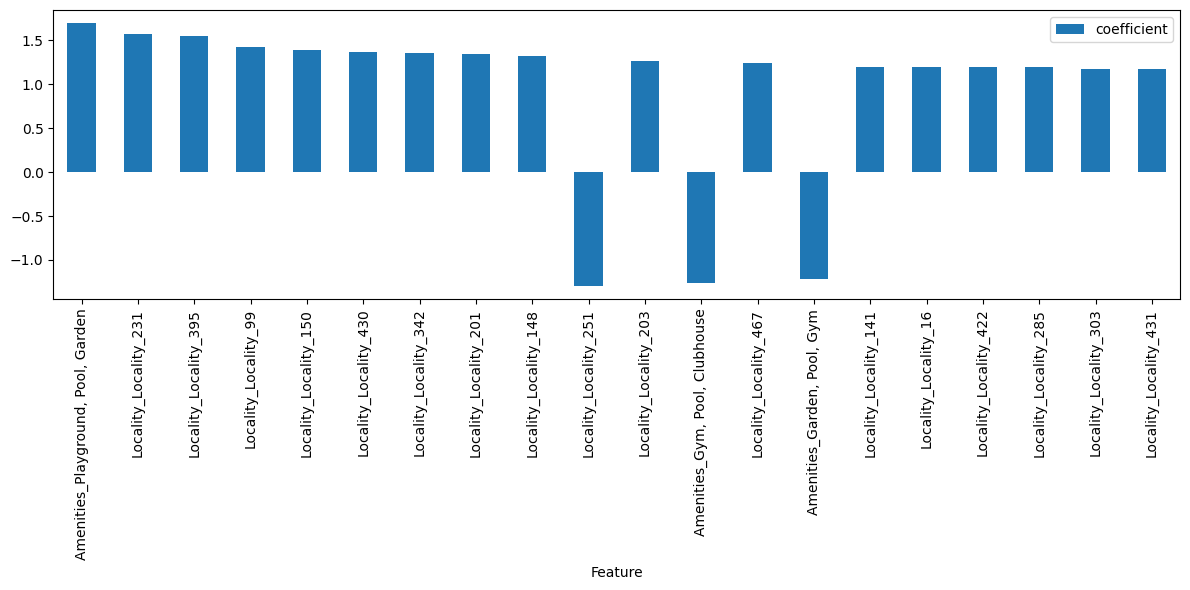

In [30]:
import	matplotlib.pyplot as plt
top20=importance.sort_values(by="coefficient", ascending=False,key=abs).head(20)
top20.plot(
  x='Feature',
		y='coefficient',
  kind='bar',
  figsize=(12, 6)
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Plain Linear Regression


mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

# Ridge Regression (alpha=1.0)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print comparison
print("Linear Regression - MSE:", mse_lr, "R²:", r2_lr)
print("Ridge Regression   - MSE:", mse_ridge, "R²:", r2_ridge)


Linear Regression - MSE: 20042.830056558854 R²: -0.008688873894596272
Ridge Regression   - MSE: 20042.823323442597 R²: -0.00868853503928313


Classification model — Logistic Regression:

Check y_clf_train.value_counts(). If one class has fewer than 35% of samples, address the imbalance using at minimum one of: (a) SMOTE from imblearn.over_sampling applied only to the training set, or (b) class_weight='balanced' in the logistic regression constructor. State which you chose and why.
Train a LogisticRegression from sklearn.linear_model on the (possibly resampled) training features and y_clf_train with max_iter=1000.
Predict class labels and probabilities on X_test_scaled.
Compute and report: confusion matrix using confusion_matrix(), accuracy, precision, recall, and F1 score using classification_report().
Compute and plot the ROC curve using roc_curve() from sklearn.metrics. Calculate and report the AUC using roc_auc_score(). Plot the ROC curve with plt.plot(), add axis labels (False Positive Rate, True Positive Rate), a title, and annotate the AUC value on the plot.
In the README: (a) write out the formulas for Precision and Recall using TP, FP, FN notation; (b) explain which metric is more important for this specific classification task and why (e.g., if false negatives are more costly than false positives, recall matters more); (c) state what the AUC value means for this model's ability to separate the two classes.

**Classification model — Logistic Regression:**


In [32]:
y_clf.value_counts()

Price_in_Lakhs
0    125001
1    124999
Name: count, dtype: int64

In [33]:
y_clf=y_clf[:100000]

In [34]:
X_final.shape

(100000, 903)

In [35]:
from sklearn .model_selection import train_test_split
X_train_clf,X_test_clf,y_train_clf,y_test_clf=train_test_split(X_final,y_clf,test_size=0.2,random_state=42,stratify=y_clf)

In [36]:
scaler.fit(X_train_clf)

c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,copy,True
,with_mean,True
,with_std,True


In [37]:
X_train_clf_scaled=scaler.transform(X_train_clf)
X_test_clf_scaled=scaler.transform(X_test_clf)

c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [38]:
from sklearn.linear_model import LogisticRegression
Lr=LogisticRegression(max_iter=1000)

In [39]:
Lr.fit(X_train_clf_scaled,y_train_clf)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
y_pred_clf=Lr.predict(X_test_clf)

c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [41]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,classification_report

In [42]:
print(f"accuracy_score:{accuracy_score(y_pred_clf,y_test_clf)}")
print(f"f1_score:{f1_score(y_pred_clf,y_test_clf)}")
print(f"precision_score:{precision_score(y_pred_clf,y_test_clf)}")
print(f"recall_score:{recall_score(y_pred_clf,y_test_clf)}")
print(f"confusion_matrix:\n{confusion_matrix(y_pred_clf,y_test_clf)}")
print(f"classification_report:{classification_report(y_pred_clf,y_test_clf)}")

accuracy_score:0.49805
f1_score:0.0
precision_score:0.0
recall_score:0.0
confusion_matrix:
[[ 9961 10039]
 [    0     0]]
classification_report:              precision    recall  f1-score   support

           0       1.00      0.50      0.66     20000
           1       0.00      0.00      0.00         0

    accuracy                           0.50     20000
   macro avg       0.50      0.25      0.33     20000
weighted avg       1.00      0.50      0.66     20000



c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

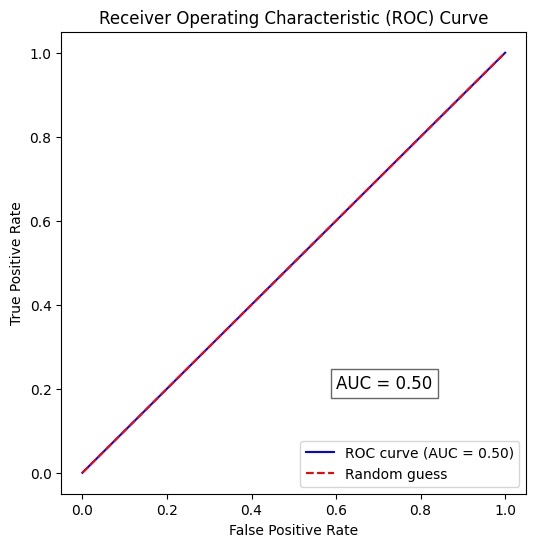

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


# 1. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_clf)

# 2. Compute AUC
auc_score = roc_auc_score(y_test_clf, y_pred_clf)

# 3. Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--", label="Random guess")

# 4. Add labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")

# 5. Annotate AUC value on the plot
plt.text(0.6, 0.2, f"AUC = {auc_score:.2f}", fontsize=12, bbox=dict(facecolor="white", alpha=0.6))

plt.show()


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predicted probabilities for the positive class
y_proba = Lr.predict_proba(X_test_clf)[:, 1]

# Thresholds to evaluate
thresholds = np.arange(0.30, 0.71, 0.10)

results = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    prec = precision_score(y_pred_clf,y_test_clf, pos_label=1)
    rec  = recall_score(y_pred_clf,y_test_clf, pos_label=1)
    f1   = f1_score(y_pred_clf,y_test_clf, pos_label=1)
    results.append([t, prec, rec, f1])

# Convert to DataFrame for tabular display
results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
print(results_df)

c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


   Threshold  Precision  Recall   F1
0        0.3        0.0     0.0  0.0
1        0.4        0.0     0.0  0.0
2        0.5        0.0     0.0  0.0
3        0.6        0.0     0.0  0.0
4        0.7        0.0     0.0  0.0


c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Baseline model (C=1.0)
log_reg_base = LogisticRegression(C=1.0, solver="liblinear", random_state=42)
log_reg_base.fit(X_train_clf_scaled,y_train_clf)
y_pred_base = log_reg_base.predict(X_test_clf)
y_proba_base = log_reg_base.predict_proba(X_test_clf)[:, 1]

prec_base = precision_score(y_test_clf, y_pred_base)
rec_base  = recall_score(y_test_clf, y_pred_base)
auc_base  = roc_auc_score(y_test_clf, y_proba_base)

# Strongly regularized model (C=0.01)
log_reg_reg = LogisticRegression(C=0.01, solver="liblinear", random_state=42)
log_reg_reg.fit(X_train_scaled, y_train_clf)
y_pred_reg = log_reg_reg.predict(X_test_clf)
y_proba_reg = log_reg_reg.predict_proba(X_test_clf)[:, 1]

prec_reg = precision_score(y_test_clf, y_pred_reg)
rec_reg  = recall_score(y_test_clf, y_pred_reg)
auc_reg  = roc_auc_score(y_test_clf, y_proba_reg)

# Comparison table
import pandas as pd
results = pd.DataFrame({
    "Model": ["LogReg (C=1.0)", "LogReg (C=0.01)"],
    "Precision": [prec_base, prec_reg],
    "Recall": [rec_base, rec_reg],
    "AUC": [auc_base, auc_reg]
})
print(results)


c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\a\OneDrive\Desktop\indian housing prices\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedM

             Model  Precision  Recall       AUC
0   LogReg (C=1.0)    0.00000     0.0  0.505457
1  LogReg (C=0.01)    0.50195     1.0  0.492852


In [52]:
import numpy as np
from sklearn.metrics import roc_auc_score

n_bootstrap = 500
rng = np.random.default_rng(seed=42)
auc_diffs = []

for _ in range(n_bootstrap):
    # 1. Sample indices with replacement
    sample_idx = rng.choice(len(y_test_clf), size=len(y_test_clf), replace=True)
    
    
    # 2. Subset labels and predictions using .iloc
    y_sample = y_test_clf.iloc[sample_idx]
    proba_c1 = y_proba_base[sample_idx]
    proba_c001 = y_proba_reg[sample_idx]
    
    # 3. Compute AUCs
    auc_c1 = roc_auc_score(y_sample, proba_c1)
    auc_c001 = roc_auc_score(y_sample, proba_c001)
    
    # 4. Store difference
    auc_diffs.append(auc_c1 - auc_c001)

# Convert to array
auc_diffs = np.array(auc_diffs)

# Mean and CI
mean_diff = np.mean(auc_diffs)
ci_lower, ci_upper = np.percentile(auc_diffs, [2.5, 98.0])

print(f"Mean AUC difference: {mean_diff:.6f}")

print(f"95% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")


Mean AUC difference: 0.012561
95% CI: [-0.002107, 0.030885]
